In [140]:
from pynq import PL
PL.reset()

In [1]:
from pynq import Overlay, MMIO
from pynq import allocate
import numpy as np
import matplotlib.pyplot as plt


In [2]:
ol = Overlay("kria_dma.bit")

print("Accesible IP-Cores:")
print(ol.ip_dict.keys())
# 
print("Accesible Memories:")
print(ol.mem_dict.keys())

Accesible IP-Cores:
dict_keys(['axi_intc_0', 'axi_dma_0', 'zynq_ultra_ps_e_0'])
Accesible Memories:
dict_keys(['PSDDR'])


In [3]:
dma = ol.axi_dma_0
dma_send = dma.sendchannel
dma_recv = dma.recvchannel

In [4]:
data_size = 50
input_buffer = allocate(shape=(data_size,), dtype=np.uint32)

In [5]:
def biexp(t, A, tau_f, tau_s):
    y = A * (np.exp(-t / tau_f) - np.exp(-t / tau_s))
    return -y

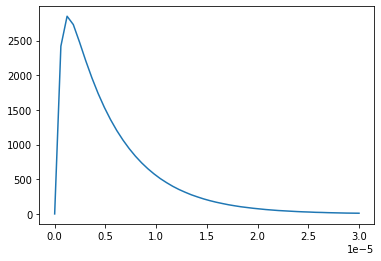

In [6]:
t= np.linspace(0, 30e-6, data_size)  # 30 µs

A = 1.0
tau_f = 0.5e-6
tau_s = 5e-6

y = biexp(t, A, tau_f, tau_s)

scale = 2**12

for i in range(data_size):
    input_buffer[i] = int(y[i] * scale)



plt.plot(t, input_buffer)
plt.show()

In [149]:
dma_send.transfer(input_buffer)

In [150]:
output_buffer = allocate(shape=(data_size,), dtype=np.uint32)

In [151]:
dma_recv.transfer(output_buffer)

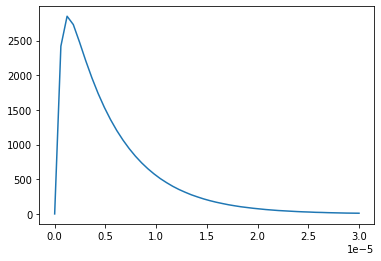

In [152]:
plt.plot(t, output_buffer)

In [153]:
del input_buffer, output_buffer